In [30]:
import os
import csv
import time
import numpy as np

data_path = "C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\data\\env_data_log_med 1.csv"
classes = ['salt-no-slip', 'salt', 'non-contact']

import pandas as pd

data = pd.read_csv(data_path)
# print(data.head())
# print shape of data
# print(data.shape)
t = data.iloc[:, 0]
x = data.iloc[:, 25:(25+17*5)]
y = data.iloc[:, -5:]
print(t.head())
print(x.head())
print(y.head())
print(x.shape)
print(y.shape)

#Split x into 5 groups of 17 columns each
X = []
for i in range(5):
    X.append(x.iloc[:, i*17:(i+1)*17].values)
X = np.array(X)
Y = y.values
print(X.shape)
print(Y.shape)


0    0.0166
1    0.0332
2    0.0498
3    0.0664
4    0.0830
Name: time, dtype: float64
     rh_ff_taxel_0     rh_ff_taxel_1     rh_ff_taxel_2    rh_ff_taxel_3  \
0  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [-0.0, 0.0, 0.0]  [0.0, 0.0, 0.0]   
1  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [-0.0, 0.0, 0.0]  [0.0, 0.0, 0.0]   
2  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [-0.0, 0.0, 0.0]  [0.0, 0.0, 0.0]   
3  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [-0.0, 0.0, 0.0]  [0.0, 0.0, 0.0]   
4  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [-0.0, 0.0, 0.0]  [0.0, 0.0, 0.0]   

      rh_ff_taxel_4    rh_ff_taxel_5     rh_ff_taxel_6     rh_ff_taxel_7  \
0  [0.0, -0.0, 0.0]  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [0.0, -0.0, 0.0]   
1  [0.0, -0.0, 0.0]  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [0.0, -0.0, 0.0]   
2  [0.0, -0.0, 0.0]  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [0.0, -0.0, 0.0]   
3  [0.0, -0.0, 0.0]  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [0.0, -0.0, 0.0]   
4  [0.0, -0.0, 0.0]  [0.0, 0.0, 0.0]  [0.0, -0.0, 0.0]  [0.0, -0.0, 0.0]   

     

In [42]:
import ast
import numpy as np
import pandas as pd

# Load source CSV from data_path defined in Cell 1
df = pd.read_csv(data_path)

fingers = ["ff", "mf", "rf", "lf", "th"]
n_taxels = 17

def parse_taxel_vector(value):
    """Parse one taxel cell into a float32 vector of length 3."""
    if isinstance(value, np.ndarray):
        arr = value.astype(np.float32).reshape(-1)
    elif isinstance(value, (list, tuple)):
        arr = np.asarray(value, dtype=np.float32).reshape(-1)
    elif isinstance(value, str):
        text = value.strip()
        try:
            parsed = ast.literal_eval(text)
            arr = np.asarray(parsed, dtype=np.float32).reshape(-1)
        except Exception:
            # Fallback for values formatted like "0.0 0.1 0.2"
            arr = np.fromstring(text.strip("[]()"), sep=" ", dtype=np.float32).reshape(-1)
    else:
        arr = np.asarray([value], dtype=np.float32).reshape(-1)

    if arr.size != 3:
        raise ValueError(f"Expected taxel vector length 3, got {arr.size} for value: {value}")

    return arr

# Build X with shape (N, 5, 17, 3)
N = len(df)
X = np.zeros((N, len(fingers), n_taxels, 3), dtype=np.float32)

for f_idx, finger in enumerate(fingers):
    for t_idx in range(n_taxels):
        col = f"rh_{finger}_taxel_{t_idx}"
        if col not in df.columns:
            raise KeyError(f"Missing required column: {col}")
        X[:, f_idx, t_idx, :] = np.vstack(df[col].apply(parse_taxel_vector).to_numpy())

# Build y with shape (N, 5) from slip columns
y_cols = [f"{finger}_slip" for finger in fingers]
missing_y = [col for col in y_cols if col not in df.columns]
if missing_y:
    raise KeyError(f"Missing required y columns: {missing_y}")

y = df[y_cols].to_numpy(dtype=np.float32)

# Optional alias for consistency with previous cells
Y = y

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Finger order:", fingers)

X shape: (3019, 5, 17, 3)
y shape: (3019, 5)
Finger order: ['ff', 'mf', 'rf', 'lf', 'th']


<class 'numpy.ndarray'> (3019,)
<class 'numpy.ndarray'> (5, 3)
0.0166 [0. 0. 0.]


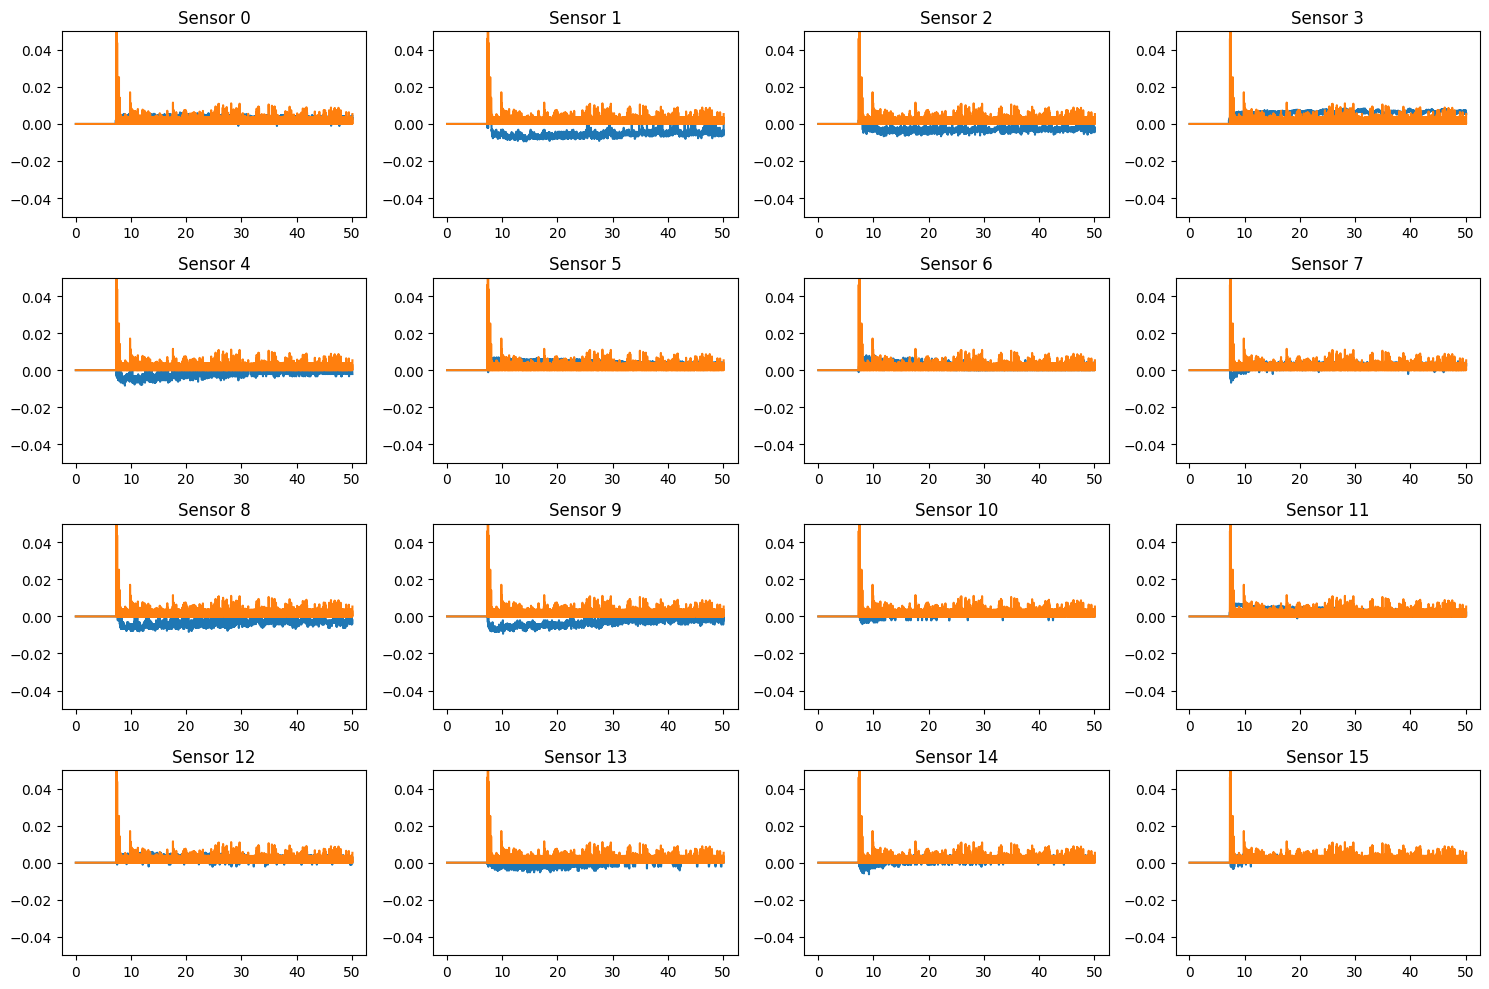

In [43]:
# Clean the y data by setting all negative values to 0
Y[Y < 0] = 0

c = 1
i = 0

# --------------------------- Plot first 16 channels across time -------------------------- #
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(15, 10))

print(type(t.values), t.values.shape)
print(type(X[0, :, 0]), X[0, :, 0].shape)
print(t.values[0], X[0, 0, 0])

X_summed = X.sum(axis=3)  # Sum across fingers to get shape (N, 5, 17)
for j in range(16):
    ax = axs[j // 4, j % 4]
    ax.plot(t.values, X_summed[ :, 0,j])
    ax.plot(t.values, Y[:, 0])  # Plot slip for first finger as reference
    ax.set_title(f'Sensor {j}')
    ax.set_ylim(-0.05,0.05 )  # Set y-axis limits for better visibility
plt.tight_layout()
plt.show()

In [47]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Resolve project path and import your LSTM model
path1 = r"D:\\UNI\\Studentermedhjaelper\\slip_severity"
path2 = r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity"
path = path1 if os.path.exists(path1) else path2
if path not in sys.path:
    sys.path.append(path)

from src.LSTM import LSTMModel

# X expected shape: (N, 5, 17, 3), y expected shape: (N, 5)
print(f"Input X shape: {X.shape}")
print(f"Target y shape: {y.shape}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

fingers = ["ff", "mf", "rf", "lf", "th"]
seq_len = 30
batch_size = 64
epochs = 12
learning_rate = 1e-3
train_fraction = 0.8

def make_sequences(x_flat, y_vec, seq_len):
    """Convert continuous timeseries into overlapping sequences for next-step regression."""
    X_seq, y_seq = [], []
    for t in range(seq_len - 1, len(x_flat)):
        X_seq.append(x_flat[t - seq_len + 1:t + 1])
        y_seq.append(y_vec[t])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32).reshape(-1, 1)

def train_one_finger_model(X_finger, y_finger, finger_name):
    # Flatten each 17x3 frame to 51 features
    x_flat = X_finger.reshape(X_finger.shape[0], -1).astype(np.float32)
    y_finger = np.where(y_finger.astype(np.float32) < 0, 0.0, y_finger.astype(np.float32))

    X_seq, y_seq = make_sequences(x_flat, y_finger, seq_len=seq_len)
    n_samples = X_seq.shape[0]
    n_train = int(n_samples * train_fraction)

    X_train, X_val = X_seq[:n_train], X_seq[n_train:]
    y_train, y_val = y_seq[:n_train], y_seq[n_train:]

    # Upweight the sparse positive-slip samples so the model does not collapse to a flat mean.
    w_train = (1.0 + 20.0 * (y_train > 0).astype(np.float32)).reshape(-1, 1)
    w_val = (1.0 + 20.0 * (y_val > 0).astype(np.float32)).reshape(-1, 1)

    train_ds = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train),
        torch.from_numpy(w_train),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val),
        torch.from_numpy(y_val),
        torch.from_numpy(w_val),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val = float("inf")
    best_state = None
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = ((pred - yb) ** 2 * wb).mean()
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_ds)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for xb, yb, wb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                wb = wb.to(device)
                pred = model(xb)
                loss = ((pred - yb) ** 2 * wb).mean()
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_ds)
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"[{finger_name}] Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val

trained_models = {}
training_history = {}
best_val_losses = {}

for f_idx, finger in enumerate(fingers):
    print(f"\nTraining model for finger: {finger}")
    model, history, best_val = train_one_finger_model(X[:, f_idx, :, :], y[:, f_idx], finger)
    trained_models[finger] = model
    training_history[finger] = history
    best_val_losses[finger] = best_val

# Save all 5 finger models
save_dir = os.path.join(path, "models")
os.makedirs(save_dir, exist_ok=True)

for finger, model in trained_models.items():
    save_path = os.path.join(save_dir, f"severity_lstm_{finger}.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Saved {finger} model to: {save_path}")

print("\nBest validation losses:")
for finger in fingers:
    print(f"{finger}: {best_val_losses[finger]:.6f}")

Input X shape: (3019, 5, 17, 3)
Target y shape: (3019, 5)
Using device: cpu

Training model for finger: ff
[ff] Epoch 01/12 | train_loss=0.001713 | val_loss=0.000047
[ff] Epoch 02/12 | train_loss=0.000163 | val_loss=0.000045
[ff] Epoch 03/12 | train_loss=0.000154 | val_loss=0.000051
[ff] Epoch 04/12 | train_loss=0.000152 | val_loss=0.000049
[ff] Epoch 05/12 | train_loss=0.000151 | val_loss=0.000057
[ff] Epoch 06/12 | train_loss=0.000149 | val_loss=0.000045
[ff] Epoch 07/12 | train_loss=0.000154 | val_loss=0.000052
[ff] Epoch 08/12 | train_loss=0.000152 | val_loss=0.000046
[ff] Epoch 09/12 | train_loss=0.000156 | val_loss=0.000048
[ff] Epoch 10/12 | train_loss=0.000158 | val_loss=0.000047
[ff] Epoch 11/12 | train_loss=0.000154 | val_loss=0.000045
[ff] Epoch 12/12 | train_loss=0.000156 | val_loss=0.000044

Training model for finger: mf
[mf] Epoch 01/12 | train_loss=0.000948 | val_loss=0.000112
[mf] Epoch 02/12 | train_loss=0.000119 | val_loss=0.000153
[mf] Epoch 03/12 | train_loss=0.0001

In [ ]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Shared 51D -> 1D model trained on all finger-specific pairs.
# Each finger contributes its own (51D input, 1D target) sequence windows to one combined dataset.
print(f"Input X shape: {X.shape}")
print(f"Target y shape: {y.shape}")

path1 = r"D:\\UNI\\Studentermedhjaelper\\slip_severity"
path2 = r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity"
path = path1 if os.path.exists(path1) else path2
if path not in sys.path:
    sys.path.append(path)

from src.LSTM import LSTMModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

fingers = ["ff", "mf", "rf", "lf", "th"]
seq_len = 15
batch_size = 64
epochs = 12
learning_rate = 1e-3
train_fraction = 0.8

def make_sequences(x_flat, y_vec, seq_len):
    X_seq, y_seq = [], []
    for t in range(seq_len - 1, len(x_flat)):
        X_seq.append(x_flat[t - seq_len + 1:t + 1])
        y_seq.append(y_vec[t])
    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32).reshape(-1, 1)

# Build a single training set from every finger's 51D -> 1D pairs.
# Negative slip values are sentinel no-slip labels, so map them to 0 and upweight the sparse positive samples.
all_X_seq = []
all_y_seq = []
all_w_seq = []

for f_idx, finger in enumerate(fingers):
    x_finger = X[:, f_idx, :, :].reshape(X.shape[0], -1).astype(np.float32)
    y_finger = np.where(y[:, f_idx].astype(np.float32) < 0, 0.0, y[:, f_idx].astype(np.float32))
    X_seq_f, y_seq_f = make_sequences(x_finger, y_finger, seq_len)
    w_seq_f = (1.0 + 20.0 * (y_seq_f > 0).astype(np.float32)).reshape(-1, 1)
    all_X_seq.append(X_seq_f)
    all_y_seq.append(y_seq_f)
    all_w_seq.append(w_seq_f)
    print(f"{finger}: X {X_seq_f.shape}, y {y_seq_f.shape}")

X_seq = np.concatenate(all_X_seq, axis=0)
y_seq = np.concatenate(all_y_seq, axis=0)
w_seq = np.concatenate(all_w_seq, axis=0)

print(f"Combined sequence input shape: {X_seq.shape}")
print(f"Combined sequence target shape: {y_seq.shape}")

# Shuffle the combined finger dataset before splitting
rng = np.random.default_rng(42)
perm = rng.permutation(len(X_seq))
X_seq = X_seq[perm]
y_seq = y_seq[perm]
w_seq = w_seq[perm]

n_samples = len(X_seq)
n_train = int(n_samples * train_fraction)

X_train, X_val = X_seq[:n_train], X_seq[n_train:]
y_train, y_val = y_seq[:n_train], y_seq[n_train:]
w_train, w_val = w_seq[:n_train], w_seq[n_train:]

train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train),
    torch.from_numpy(w_train),
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val),
    torch.from_numpy(w_val),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

# One shared model: 51D input -> 1D output
model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

best_val = float("inf")
best_state = None
history = {"train": [], "val": []}

for epoch in range(1, epochs + 1):
    model.train()
    train_loss_sum = 0.0

    for xb, yb, wb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        wb = wb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = ((pred - yb) ** 2 * wb).mean()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)

    train_loss = train_loss_sum / len(train_ds)

    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for xb, yb, wb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)
            pred = model(xb)
            loss = ((pred - yb) ** 2 * wb).mean()
            val_loss_sum += loss.item() * xb.size(0)

    val_loss = val_loss_sum / len(val_ds)
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

if best_state is not None:
    model.load_state_dict(best_state)

save_dir = os.path.join(path, "models")
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "severity_lstm_shared_51d_1d.pth")
torch.save(model.state_dict(), save_path)

print(f"Saved model to: {save_path}")
print(f"Best validation loss: {best_val:.6f}")

Input X shape: (3019, 5, 17, 3)
Target y shape: (3019, 5)
Using device: cpu
ff: X (2990, 30, 51), y (2990, 1)
mf: X (2990, 30, 51), y (2990, 1)
rf: X (2990, 30, 51), y (2990, 1)
lf: X (2990, 30, 51), y (2990, 1)
th: X (2990, 30, 51), y (2990, 1)
Combined sequence input shape: (14950, 30, 51)
Combined sequence target shape: (14950, 1)
Epoch 01/12 | train_loss=0.002008 | val_loss=0.001851
Epoch 02/12 | train_loss=0.001640 | val_loss=0.001228
Epoch 03/12 | train_loss=0.001549 | val_loss=0.001452
Epoch 04/12 | train_loss=0.001463 | val_loss=0.001160
Epoch 05/12 | train_loss=0.001459 | val_loss=0.001420
Epoch 06/12 | train_loss=0.001339 | val_loss=0.001208
Epoch 07/12 | train_loss=0.001341 | val_loss=0.001198
Epoch 08/12 | train_loss=0.001357 | val_loss=0.001165
Epoch 09/12 | train_loss=0.001403 | val_loss=0.001159
Epoch 10/12 | train_loss=0.001331 | val_loss=0.001144
Epoch 11/12 | train_loss=0.001292 | val_loss=0.001119
Epoch 12/12 | train_loss=0.001305 | val_loss=0.001274
Saved model to: 

First finger input shape: (3019, 51)
Rolling windows shape: (2990, 30, 51)
Prediction shape: (2990,)
Ground truth shape: (2990,)
Prediction range: 0.000863 to 0.007581
Ground truth range: 0.000000 to 0.075921


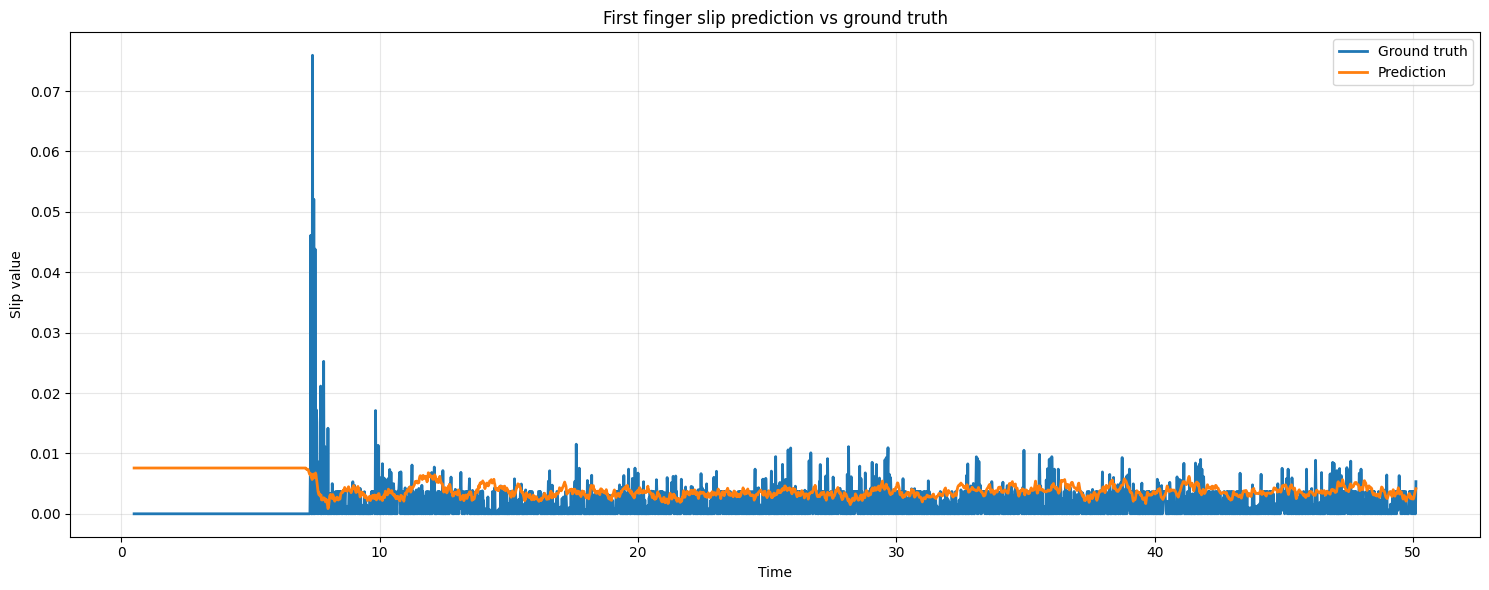

In [51]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

# Sweep the first finger (ff) data through the weighted shared 51D -> 1D model
finger_idx = 0
seq_len = 30

path1 = r"D:\\UNI\\Studentermedhjaelper\\slip_severity"
path2 = r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity"
path = path1 if os.path.exists(path1) else path2
if path not in sys.path:
    sys.path.append(path)

from src.LSTM import LSTMModel

save_path = os.path.join(path, "models", "severity_lstm_shared_51d_1d.pth")
if not os.path.exists(save_path):
    raise FileNotFoundError(f"Missing model checkpoint: {save_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=1).to(device)
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

# Build the first-finger 51D time series and sweep a rolling window across time
x_ff = X[:, finger_idx, :, :].reshape(X.shape[0], -1).astype(np.float32)
y_ff = np.where(y[:, finger_idx].astype(np.float32) < 0, 0.0, y[:, finger_idx].astype(np.float32))
t_vals = t.to_numpy() if hasattr(t, "to_numpy") else np.asarray(t)

x_windows = []
for idx in range(seq_len - 1, len(x_ff)):
    x_windows.append(x_ff[idx - seq_len + 1:idx + 1])
x_windows = np.asarray(x_windows, dtype=np.float32)

with torch.no_grad():
    pred_ff = model(torch.from_numpy(x_windows).to(device)).cpu().numpy().squeeze(-1)

y_ff_trimmed = y_ff[seq_len - 1:]
t_trimmed = t_vals[seq_len - 1:]

print(f"First finger input shape: {x_ff.shape}")
print(f"Rolling windows shape: {x_windows.shape}")
print(f"Prediction shape: {pred_ff.shape}")
print(f"Ground truth shape: {y_ff_trimmed.shape}")
print(f"Prediction range: {pred_ff.min():.6f} to {pred_ff.max():.6f}")
print(f"Ground truth range: {y_ff_trimmed.min():.6f} to {y_ff_trimmed.max():.6f}")

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(t_trimmed, y_ff_trimmed, label="Ground truth", linewidth=2)
ax.plot(t_trimmed, pred_ff, label="Prediction", linewidth=2)
ax.set_title("First finger slip prediction vs ground truth")
ax.set_xlabel("Time")
ax.set_ylabel("Slip value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# import lstm_model.pth

import torch
import sys

path1 = r"D:\\UNI\\Studentermedhjaelper\\slip_severity"
path2 = r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity"
path = path1 if os.path.exists(path1) else path2

sys.path.append(path)
from src.LSTM import LSTMModel
import sys


model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=1)
model.load_state_dict(torch.load(os.path.join(path, "lstm_model.pth"), map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")



data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


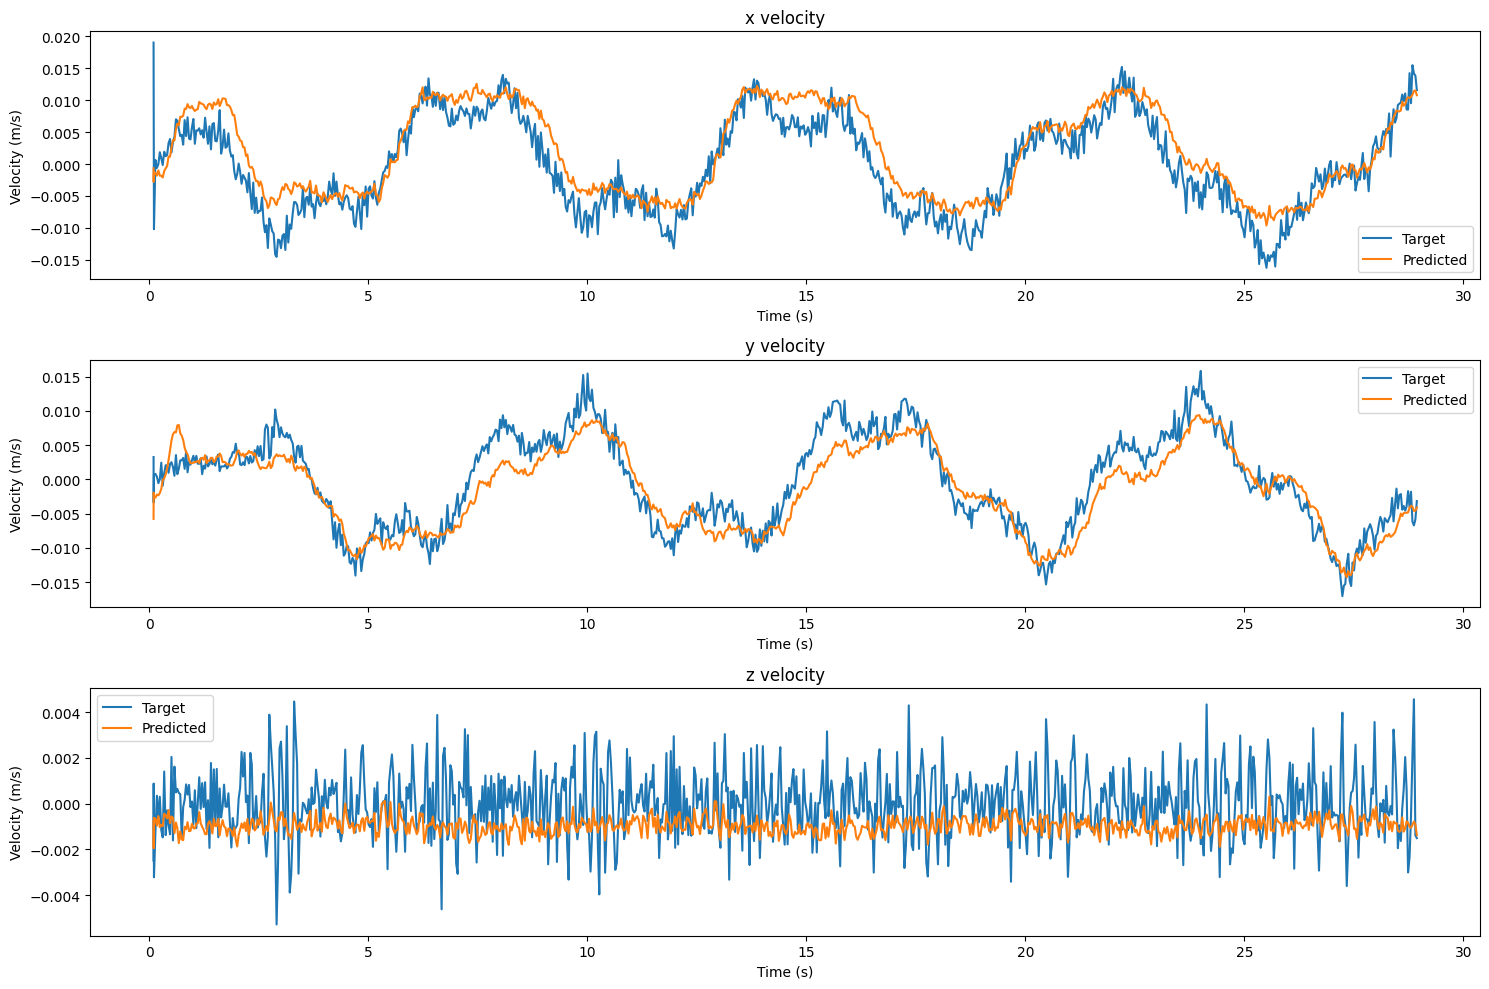

In [4]:
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.tight_layout()
plt.show()

63 63
43 43


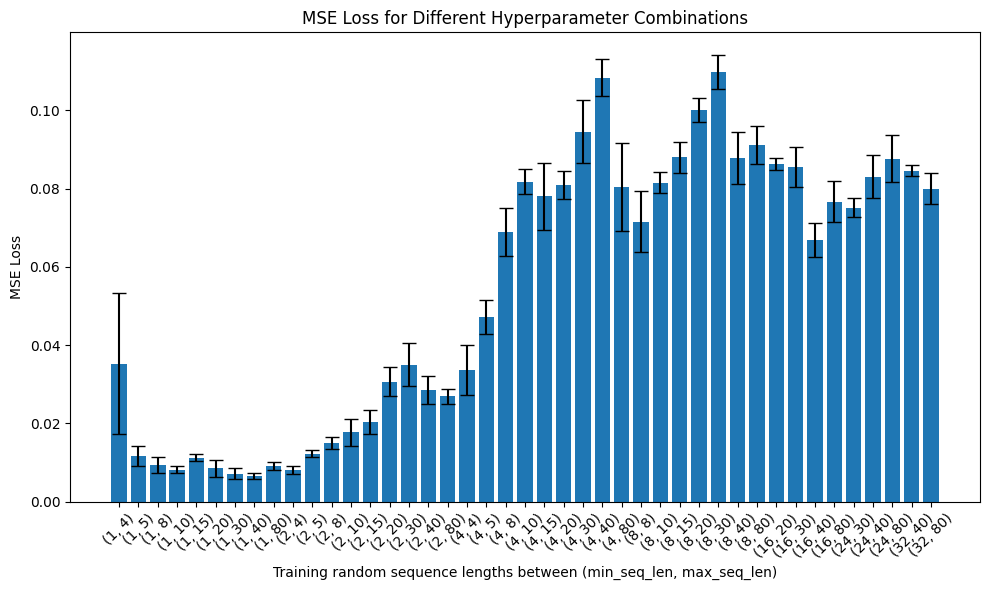

In [13]:
# ---------------------------------------------------------------------------- #
#                        PLOT OF MSE FOR PARAMETER SWEEP                       #
# ---------------------------------------------------------------------------- #
nan = "nan"
loss_dict={(1, 4): [0.05382377112453634, 0.06012919274243442, 0.025783700953153046, 0.0209622879258611, 0.015853937334296377], (1, 5): [0.012402488299730148, 0.011037449775771662, 0.007290823131122373, 0.015491691417992115, 0.012226154265755957], (1, 8): [0.012564135461368343, 0.006868350107900121, 0.009443033952265978, 0.007628244093873284, 0.010832938365638256], (1, 10): [0.007551602553576231, 0.008623278403485363, 0.006958869201215831, 0.00854020273651589, 0.009341414213519205], (1, 15): [0.01100219769234007, 0.011112279935993931, 0.009872523305768316, 0.011805106039074335, 0.012424229644238949], (1, 20): [0.012412223202938383, 0.009516702372242104, 0.007381935476918112, 0.00576931991699067, 0.007450251924720677], (1, 30): [0.008451578630642458, 0.007481678473678502, 0.00882592306218364, 0.005517782071943988, 0.005595925623889674], (1, 40): [0.0056993966414169836, 0.006791027918965979, 0.005861435530029915, 0.00767862508920106, 0.007292749635367231], (1, 80): [0.008176555052738298, 0.009426322553984144, 0.01073530087755485, 0.0089509209448641, 0.007983408063988794], (2, 4): [0.007089019202711907, 0.008903042286295782, 0.007306581024419178, 0.007879220287908207, 0.00981148886917667], (2, 5): [0.01087638409808278, 0.013015159659764984, 0.012986686842685396, 0.012950779023495588, 0.011481558438390493], (2, 8): [0.01311340851878578, 0.013499305414205248, 0.017387617379426956, 0.01478545189919797, 0.016206375661898743], (2, 10): [0.015607457692650232, 0.02092566823756153, 0.01598270863971927, 0.013577417174184864, 0.022730124352330513], (2, 15): [0.01471711898391897, 0.01896878374232487, 0.0227771672335538, 0.022504963404075665, 0.02278446617790244], (2, 20): [0.026845024559985508, 0.029023799706589092, 0.0275676478208466, 0.03630321218886159, 0.03376829200847582], (2, 30): [0.02997898208824071, 0.04296846687793732, 0.03991942768069831, 0.02913442931391976, 0.03295767730609937], (2, 40): [0.03429179012098096, 0.028947828676212917, 0.02897160237824375, 0.027580468153411693, 0.02291209547018463], (2, 80): [0.030619289895350284, 0.02516479790210724, 0.026011911644177002, 0.02582139242440462, 0.02722257189452648], (4, 4): [0.02705547357486053, 0.02928874133662744, 0.03263700871982358, 0.03365945274179632, 0.04546688361601396], (4, 5): [0.0396345950324427, 0.049931886182589966, 0.04580311900512739, 0.05244122411717068, 0.048296387900005684], (4, 8): [0.06425830586390062, 0.061418403278697624, 0.0666001784530553, 0.07769820805300366, 0.07423225722529671], (4, 10): [0.07782179354266687, 0.08356583660299127, 0.08102038875222206, 0.08691102063113992, 0.07944614135406235], (4, 15): [0.08319417929107492, 0.08719175139611418, 0.08278767222707922, 0.06354746798222716, 0.07323481007055803], (4, 20): [0.079818571833047, 0.0798405185341835, 0.08688531206412749, 0.0756061930548061, 0.08238055049018427], (4, 30): [0.09462146596475081, 0.08320696076208894, 0.08812135322527452, 0.10322876680981029, 0.10324404727328908], (4, 40): [0.10227871483022516, 0.10956845703450116, 0.11284229227087715, 0.10311779244379564, 0.11367839100685986], (4, 80): [0.06828419830311429, 0.09823434258049185, 0.07886159894141284, 0.06921468641270291, 0.08736831017515877], (8, 4): [], (8, 5): [], (8, 8): [0.06462949785319241, 0.060453558510000054, 0.07440475509925322, 0.07904491099444302, 0.07932049510153857], (8, 10): [0.07808931612155655, 0.07946635681119832, 0.0811424312943762, 0.08593812449411913, 0.08287334476004947], (8, 15): [0.08536159145561131, 0.08660862425511534, 0.08312218128280206, 0.09374430267648264, 0.09080792760307138], (8, 20): [0.0970741838894107, 0.09612636539069089, 0.10441661355170337, 0.10154559260064905, 0.10116628015583212], (8, 30): [0.11446657099507072, 0.10858175564895976, 0.10667708583853462, 0.10381069169803099, 0.1152138655835932], (8, 40): [0.09711303765123541, 0.0823600021275607, 0.08306659995154901, 0.09470832957462831, 0.08201982995325868], (8, 80): [0.09294790402054787, 0.08242522688074545, 0.09152353351766412, 0.09103055366060951, 0.0973639650778337], (16, 4): [], (16, 5): [], (16, 8): [], (16, 10): [], (16, 15): [], (16, 20): [0.08471590415997939, 0.08641325750134209, 0.08907881785522807, 0.08521410789002072, 0.08590896224433725], (16, 30): [0.07945173233747482, 0.0898131670599634, 0.081165650351481, 0.09320479021830992, 0.08399601856415922], (16, 40): [0.07281260361725633, 0.05930510874498974, 0.06718700717795979, 0.0671413628892465, 0.06739962338046594], (16, 80): [0.0685053061355244, 0.07755559987642548, 0.08261467516422272, 0.0815064778382128, 0.07299261235378006], (24, 4): [], (24, 5): [], (24, 8): [], (24, 10): [], (24, 15): [], (24, 20): [], (24, 30): [0.07817047089338303, 0.07647502998059447, 0.0742047679695216, 0.07086151296442206, 0.07563270865516229], (24, 40): [0.08817941695451736, 0.0721738263964653, 0.08553533425385301, 0.08500507812608372, 0.08439896323464134], (24, 80): [0.08474667878313498, 0.09359465403990312, 0.08625890856439417, 0.09479928829453209, 0.07894961671395735], (32, 4): [], (32, 5): [], (32, 8): [], (32, 10): [], (32, 15): [], (32, 20): [], (32, 30): [], (32, 40): [0.08512841029600664, 0.08662752129814842, 0.08502810956402258, 0.08246044780720364, 0.08377093483101238], (32, 80): [0.08275932920250026, 0.08238381486047398, 0.08344121751460162, 0.07802903381260959, 0.07304305380040949]}
loss_std_dict={(1, 4): np.float64(0.01807704421475727), (1, 5): np.float64(0.002646754130713055), (1, 8): np.float64(0.0020781055806147336), (1, 10): np.float64(0.0008436239202665605), (1, 15): np.float64(0.0008561011821302187), (1, 20): np.float64(0.002286816209764041), (1, 30): np.float64(0.0013920558823419362), (1, 40): np.float64(0.0007765943011444161), (1, 80): np.float64(0.0009891508972955185), (2, 4): np.float64(0.0010224008583698068), (2, 5): np.float64(0.0009050809279241876), (2, 8): np.float64(0.0016132817011230165), (2, 10): np.float64(0.0034643811637468714), (2, 15): np.float64(0.003165398529921432), (2, 20): np.float64(0.0036957408783477434), (2, 30): np.float64(0.005504244161473197), (2, 40): np.float64(0.003633997862802182), (2, 80): np.float64(0.0019430427906510512), (4, 4): np.float64(0.00637446903124998), (4, 5): np.float64(0.004366234733326334), (4, 8): np.float64(0.00614219987779108), (4, 10): np.float64(0.0032001329233877786), (4, 15): np.float64(0.008555371705312809), (4, 20): np.float64(0.003696814198043431), (4, 30): np.float64(0.008011031872202111), (4, 40): np.float64(0.004780786571226388), (4, 80): np.float64(0.011321584860895127), (8, 4): np.float64(nan), (8, 5): np.float64(nan), (8, 8): np.float64(0.007690593534265835), (8, 10): np.float64(0.0027378579598738005), (8, 15): np.float64(0.003835269332303314), (8, 20): np.float64(0.003059389915323256), (8, 30): np.float64(0.004431316925706031), (8, 40): np.float64(0.006631023498021043), (8, 80): np.float64(0.004859612720699199), (16, 4): np.float64(nan), (16, 5): np.float64(nan), (16, 8): np.float64(nan), (16, 10): np.float64(nan), (16, 15): np.float64(nan), (16, 20): np.float64(0.0015212086590137815), (16, 30): np.float64(0.005207568341079779), (16, 40): np.float64(0.0043115168379493345), (16, 80): np.float64(0.005285720870498614), (24, 4): np.float64(nan), (24, 5): np.float64(nan), (24, 8): np.float64(nan), (24, 10): np.float64(nan), (24, 15): np.float64(nan), (24, 20): np.float64(nan), (24, 30): np.float64(0.0024642911176187424), (24, 40): np.float64(0.005593221360059876), (24, 80): np.float64(0.005873846228247211), (32, 4): np.float64(nan), (32, 5): np.float64(nan), (32, 8): np.float64(nan), (32, 10): np.float64(nan), (32, 15): np.float64(nan), (32, 20): np.float64(nan), (32, 30): np.float64(nan), (32, 40): np.float64(0.0014027346802305864), (32, 80): np.float64(0.003934428843522092)}
print(len(loss_dict), len(loss_std_dict))
loss_std_dict = {k: v for k, v in loss_std_dict.items() if not np.isnan(v)}
loss_dict = {k: v for k, v in loss_dict.items() if k in loss_std_dict}
loss_mean_dict = {k: np.mean(v) for k, v in loss_dict.items()}

print(len(loss_dict), len(loss_std_dict))

# plot loss_dict with error bars from loss_std_dict
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(loss_dict))
y = [loss_mean_dict[k] for k in loss_dict.keys()]
ax.bar(x, y, yerr=[loss_std_dict[k] for k in loss_dict.keys()], capsize=5)
ax.set_xticks(x)
ax.set_xticklabels([f"({k[0]}, {k[1]})" for k in loss_dict.keys()], rotation=45)
ax.set_xlabel('Training random sequence lengths between (min_seq_len, max_seq_len)')
ax.set_ylabel('MSE Loss')
ax.set_title('MSE Loss for Different Hyperparameter Combinations')
plt.tight_layout()
plt.show()





In [ ]:
# ---------------------------------------------------------------------------- #
#                        PLOT OF MSE FOR PARAMETER SWEEP                       #
# ---------------------------------------------------------------------------- #
nan = "nan"
loss_dict={(1, 4): [0.05382377112453634, 0.06012919274243442, 0.025783700953153046, 0.0209622879258611, 0.015853937334296377], (1, 5): [0.012402488299730148, 0.011037449775771662, 0.007290823131122373, 0.015491691417992115, 0.012226154265755957], (1, 8): [0.012564135461368343, 0.006868350107900121, 0.009443033952265978, 0.007628244093873284, 0.010832938365638256], (1, 10): [0.007551602553576231, 0.008623278403485363, 0.006958869201215831, 0.00854020273651589, 0.009341414213519205], (1, 15): [0.01100219769234007, 0.011112279935993931, 0.009872523305768316, 0.011805106039074335, 0.012424229644238949], (1, 20): [0.012412223202938383, 0.009516702372242104, 0.007381935476918112, 0.00576931991699067, 0.007450251924720677], (1, 30): [0.008451578630642458, 0.007481678473678502, 0.00882592306218364, 0.005517782071943988, 0.005595925623889674], (1, 40): [0.0056993966414169836, 0.006791027918965979, 0.005861435530029915, 0.00767862508920106, 0.007292749635367231], (1, 80): [0.008176555052738298, 0.009426322553984144, 0.01073530087755485, 0.0089509209448641, 0.007983408063988794], (2, 4): [0.007089019202711907, 0.008903042286295782, 0.007306581024419178, 0.007879220287908207, 0.00981148886917667], (2, 5): [0.01087638409808278, 0.013015159659764984, 0.012986686842685396, 0.012950779023495588, 0.011481558438390493], (2, 8): [0.01311340851878578, 0.013499305414205248, 0.017387617379426956, 0.01478545189919797, 0.016206375661898743], (2, 10): [0.015607457692650232, 0.02092566823756153, 0.01598270863971927, 0.013577417174184864, 0.022730124352330513], (2, 15): [0.01471711898391897, 0.01896878374232487, 0.0227771672335538, 0.022504963404075665, 0.02278446617790244], (2, 20): [0.026845024559985508, 0.029023799706589092, 0.0275676478208466, 0.03630321218886159, 0.03376829200847582], (2, 30): [0.02997898208824071, 0.04296846687793732, 0.03991942768069831, 0.02913442931391976, 0.03295767730609937], (2, 40): [0.03429179012098096, 0.028947828676212917, 0.02897160237824375, 0.027580468153411693, 0.02291209547018463], (2, 80): [0.030619289895350284, 0.02516479790210724, 0.026011911644177002, 0.02582139242440462, 0.02722257189452648], (4, 4): [0.02705547357486053, 0.02928874133662744, 0.03263700871982358, 0.03365945274179632, 0.04546688361601396], (4, 5): [0.0396345950324427, 0.049931886182589966, 0.04580311900512739, 0.05244122411717068, 0.048296387900005684], (4, 8): [0.06425830586390062, 0.061418403278697624, 0.0666001784530553, 0.07769820805300366, 0.07423225722529671], (4, 10): [0.07782179354266687, 0.08356583660299127, 0.08102038875222206, 0.08691102063113992, 0.07944614135406235], (4, 15): [0.08319417929107492, 0.08719175139611418, 0.08278767222707922, 0.06354746798222716, 0.07323481007055803], (4, 20): [0.079818571833047, 0.0798405185341835, 0.08688531206412749, 0.0756061930548061, 0.08238055049018427], (4, 30): [0.09462146596475081, 0.08320696076208894, 0.08812135322527452, 0.10322876680981029, 0.10324404727328908], (4, 40): [0.10227871483022516, 0.10956845703450116, 0.11284229227087715, 0.10311779244379564, 0.11367839100685986], (4, 80): [0.06828419830311429, 0.09823434258049185, 0.07886159894141284, 0.06921468641270291, 0.08736831017515877], (8, 4): [], (8, 5): [], (8, 8): [0.06462949785319241, 0.060453558510000054, 0.07440475509925322, 0.07904491099444302, 0.07932049510153857], (8, 10): [0.07808931612155655, 0.07946635681119832, 0.0811424312943762, 0.08593812449411913, 0.08287334476004947], (8, 15): [0.08536159145561131, 0.08660862425511534, 0.08312218128280206, 0.09374430267648264, 0.09080792760307138], (8, 20): [0.0970741838894107, 0.09612636539069089, 0.10441661355170337, 0.10154559260064905, 0.10116628015583212], (8, 30): [0.11446657099507072, 0.10858175564895976, 0.10667708583853462, 0.10381069169803099, 0.1152138655835932], (8, 40): [0.09711303765123541, 0.0823600021275607, 0.08306659995154901, 0.09470832957462831, 0.08201982995325868], (8, 80): [0.09294790402054787, 0.08242522688074545, 0.09152353351766412, 0.09103055366060951, 0.0973639650778337], (16, 4): [], (16, 5): [], (16, 8): [], (16, 10): [], (16, 15): [], (16, 20): [0.08471590415997939, 0.08641325750134209, 0.08907881785522807, 0.08521410789002072, 0.08590896224433725], (16, 30): [0.07945173233747482, 0.0898131670599634, 0.081165650351481, 0.09320479021830992, 0.08399601856415922], (16, 40): [0.07281260361725633, 0.05930510874498974, 0.06718700717795979, 0.0671413628892465, 0.06739962338046594], (16, 80): [0.0685053061355244, 0.07755559987642548, 0.08261467516422272, 0.0815064778382128, 0.07299261235378006], (24, 4): [], (24, 5): [], (24, 8): [], (24, 10): [], (24, 15): [], (24, 20): [], (24, 30): [0.07817047089338303, 0.07647502998059447, 0.0742047679695216, 0.07086151296442206, 0.07563270865516229], (24, 40): [0.08817941695451736, 0.0721738263964653, 0.08553533425385301, 0.08500507812608372, 0.08439896323464134], (24, 80): [0.08474667878313498, 0.09359465403990312, 0.08625890856439417, 0.09479928829453209, 0.07894961671395735], (32, 4): [], (32, 5): [], (32, 8): [], (32, 10): [], (32, 15): [], (32, 20): [], (32, 30): [], (32, 40): [0.08512841029600664, 0.08662752129814842, 0.08502810956402258, 0.08246044780720364, 0.08377093483101238], (32, 80): [0.08275932920250026, 0.08238381486047398, 0.08344121751460162, 0.07802903381260959, 0.07304305380040949]}
loss_std_dict={(1, 4): np.float64(0.01807704421475727), (1, 5): np.float64(0.002646754130713055), (1, 8): np.float64(0.0020781055806147336), (1, 10): np.float64(0.0008436239202665605), (1, 15): np.float64(0.0008561011821302187), (1, 20): np.float64(0.002286816209764041), (1, 30): np.float64(0.0013920558823419362), (1, 40): np.float64(0.0007765943011444161), (1, 80): np.float64(0.0009891508972955185), (2, 4): np.float64(0.0010224008583698068), (2, 5): np.float64(0.0009050809279241876), (2, 8): np.float64(0.0016132817011230165), (2, 10): np.float64(0.0034643811637468714), (2, 15): np.float64(0.003165398529921432), (2, 20): np.float64(0.0036957408783477434), (2, 30): np.float64(0.005504244161473197), (2, 40): np.float64(0.003633997862802182), (2, 80): np.float64(0.0019430427906510512), (4, 4): np.float64(0.00637446903124998), (4, 5): np.float64(0.004366234733326334), (4, 8): np.float64(0.00614219987779108), (4, 10): np.float64(0.0032001329233877786), (4, 15): np.float64(0.008555371705312809), (4, 20): np.float64(0.003696814198043431), (4, 30): np.float64(0.008011031872202111), (4, 40): np.float64(0.004780786571226388), (4, 80): np.float64(0.011321584860895127), (8, 4): np.float64(nan), (8, 5): np.float64(nan), (8, 8): np.float64(0.007690593534265835), (8, 10): np.float64(0.0027378579598738005), (8, 15): np.float64(0.003835269332303314), (8, 20): np.float64(0.003059389915323256), (8, 30): np.float64(0.004431316925706031), (8, 40): np.float64(0.006631023498021043), (8, 80): np.float64(0.004859612720699199), (16, 4): np.float64(nan), (16, 5): np.float64(nan), (16, 8): np.float64(nan), (16, 10): np.float64(nan), (16, 15): np.float64(nan), (16, 20): np.float64(0.0015212086590137815), (16, 30): np.float64(0.005207568341079779), (16, 40): np.float64(0.0043115168379493345), (16, 80): np.float64(0.005285720870498614), (24, 4): np.float64(nan), (24, 5): np.float64(nan), (24, 8): np.float64(nan), (24, 10): np.float64(nan), (24, 15): np.float64(nan), (24, 20): np.float64(nan), (24, 30): np.float64(0.0024642911176187424), (24, 40): np.float64(0.005593221360059876), (24, 80): np.float64(0.005873846228247211), (32, 4): np.float64(nan), (32, 5): np.float64(nan), (32, 8): np.float64(nan), (32, 10): np.float64(nan), (32, 15): np.float64(nan), (32, 20): np.float64(nan), (32, 30): np.float64(nan), (32, 40): np.float64(0.0014027346802305864), (32, 80): np.float64(0.003934428843522092)}
print(len(loss_dict), len(loss_std_dict))
loss_std_dict = {k: v for k, v in loss_std_dict.items() if not np.isnan(v)}
loss_dict = {k: v for k, v in loss_dict.items() if k in loss_std_dict}
loss_mean_dict = {k: np.mean(v) for k, v in loss_dict.items()}

print(len(loss_dict), len(loss_std_dict))

# plot loss_dict with error bars from loss_std_dict
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(loss_dict))
y = [loss_mean_dict[k] for k in loss_dict.keys()]
first_key_vals = [k[0] for k in loss_dict.keys()]
unique_first_key_vals = sorted(set(first_key_vals))
color_map = {v: plt.cm.tab10(i % 10) for i, v in enumerate(unique_first_key_vals)}
bar_colors = [color_map[v] for v in first_key_vals]
#no colours:

ax.bar(
    x,
    y,
    yerr=[loss_std_dict[k] for k in loss_dict.keys()],
    capsize=5,
    color=bar_colors
)

ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=color_map[v], label=f"{v}") for v in unique_first_key_vals],
    title="First key value"
)
ax.set_xticks(x)
ax.set_xticklabels([f"({k[0]}, {k[1]})" for k in loss_dict.keys()], rotation=45)
ax.set_xlabel('Training random sequence lengths between (min_seq_len, max_seq_len)')
ax.set_ylabel('MSE Loss')
ax.set_title('MSE Loss for Different Hyperparameter Combinations')
plt.tight_layout()
plt.show()





data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


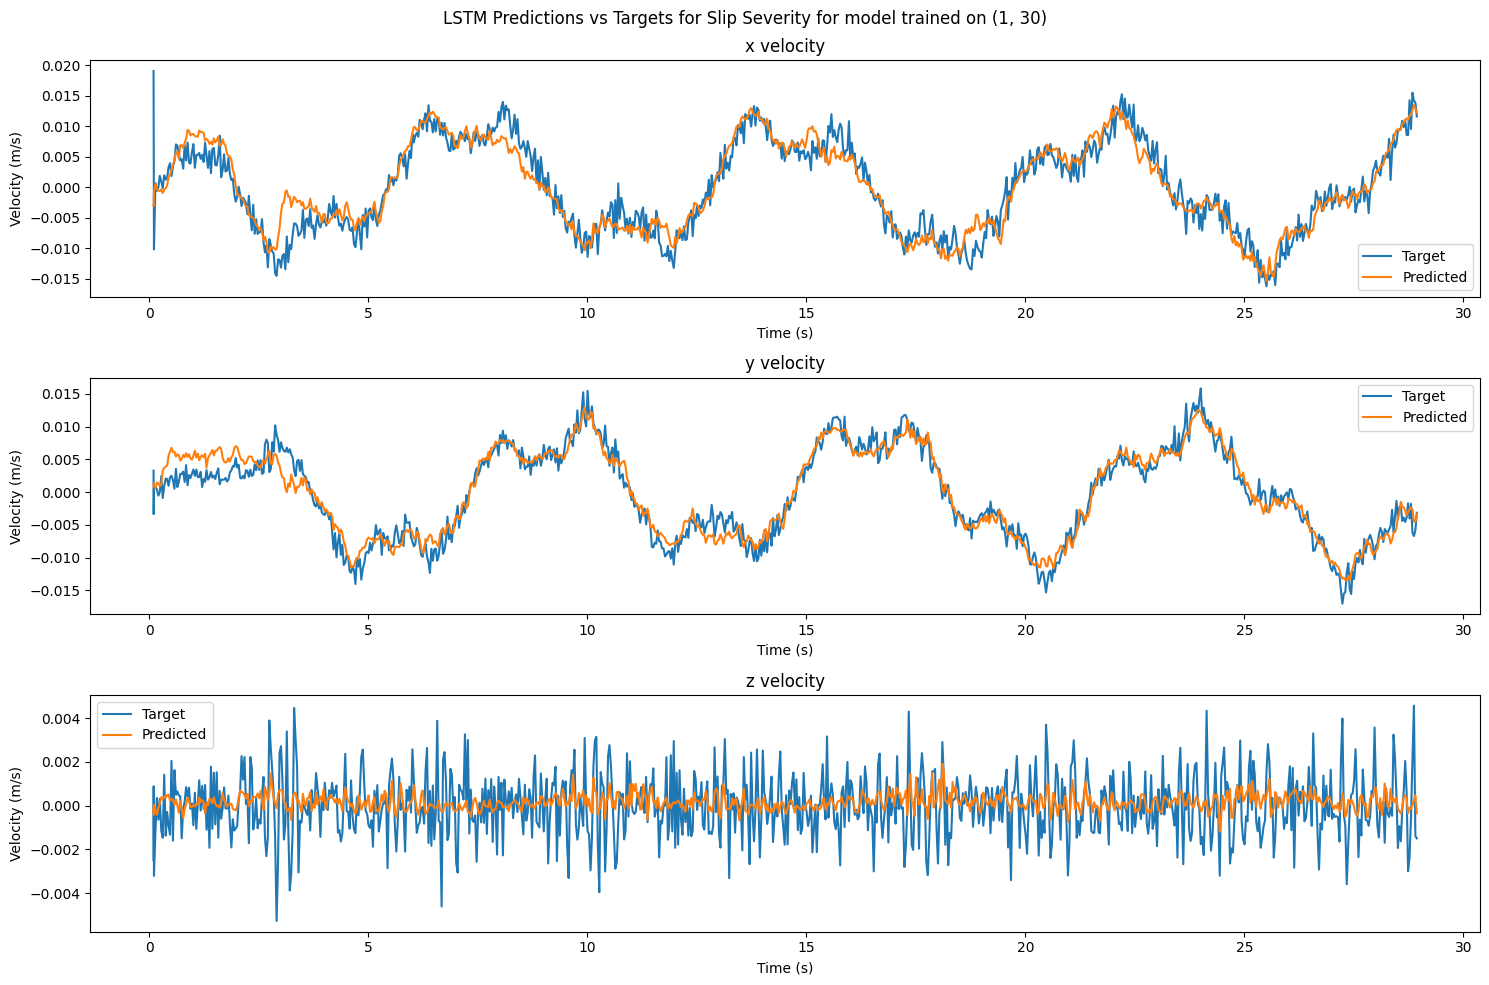

In [17]:
model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=3)
model.load_state_dict(torch.load(os.path.join(path, "lstm_model_1-30.pth"), map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.suptitle('LSTM Predictions vs Targets for Slip Severity for model trained on (1, 30)')
plt.tight_layout()
plt.show()

data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


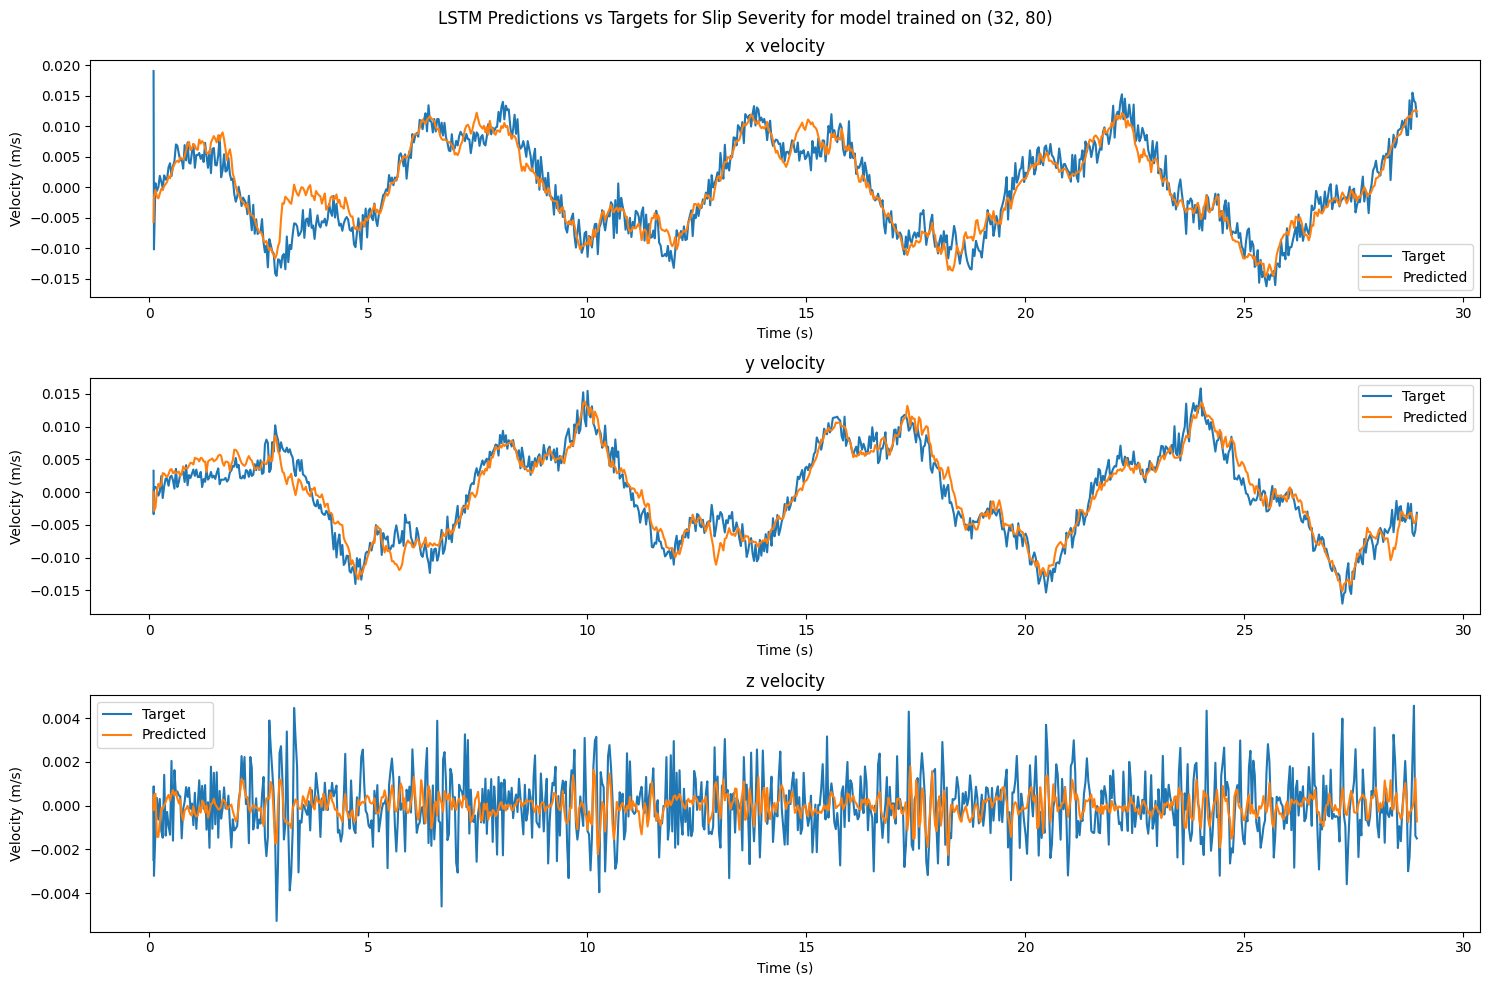

In [22]:
model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=3)
model.load_state_dict(torch.load(os.path.join(path, "lstm_model_32-80.pth"), map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.suptitle('LSTM Predictions vs Targets for Slip Severity for model trained on (32, 80)')
plt.tight_layout()
plt.show()